#Initial Data Load & Cleanup
The below block pulls data directly from the City of Calgary Open Data Portal, and performs various wrangling procedures to prepare them for use in the model

In [ ]:
import pandas as pd
import geopandas as gpd

def get_data():
  datalist = {}
  datalist['incidents'] = 'https://data.calgary.ca/resource/35ra-9556.geojson'
  datalist['equity'] = 'https://data.calgary.ca/resource/7g5f-dkmi.geojson'

  limit = 25000 #of records to pull from city of calgary website per chunk
  dataframes = {}
  for key, value in datalist.items(): #key, value = destination dataframe name & retrieval URL
    chunks = [] #chunks of 25000 (limit)
    offset = 0 #start at zero
    while True: #keep looping until there are no more chunks of 25000
        url = f"{value}?$limit={limit}&$offset={offset}" #dynamically regenerate URL
        gdf = gpd.read_file(url)
        if gdf.empty:
            break
        chunks.append(gdf)
        offset += limit
    dataframes[key] = pd.concat(chunks) # Store dataframe in the dictionary
  return dataframes

def refine_incidents(dataframes):
  df_incidents = dataframes['incidents']
  df_incidents = df_incidents.dropna().copy()
  df_incidents['Year'] = pd.to_datetime(df_incidents['start_dt']).dt.year #Add Year Calculation
  df_incidents = df_incidents[['Year', 'geometry']] #filter columns
  renameColumns = {'Year':'Incident Year', 'geometry':'Incident Geometry'}
  df_incidents = df_incidents.rename(columns=renameColumns) #rename columns
  filteryears = [2022, 2023, 2024]
  df_incidents = df_incidents[df_incidents['Incident Year'].isin(filteryears)] #filter years
  df_incidents = df_incidents.set_geometry('Incident Geometry') # Set the active geometry column
  df_incidents = df_incidents.to_crs(epsg=3395)
  df_incidents.to_csv('df_incidents.csv', index=False)
  return df_incidents

def refine_equity(dataframes):
  df_equity = dataframes['equity']
  df_equity = df_equity.dropna().copy()
  df_equity = df_equity[df_equity['area_type'] == 'CSA'].copy()
  df_equity = df_equity.rename(columns={'area_id': 'csa'})
  df_equity['value'] = pd.to_numeric(df_equity['value'], errors='coerce').fillna(0)
  columns_to_keep = ['csa', 'geometry', 'attribute', 'value']
  df_equity = df_equity[columns_to_keep]
  df_equity = df_equity.pivot_table(index=['csa', 'geometry'],
                                          columns='attribute',
                                          values='value').reset_index()
  df_equity = gpd.GeoDataFrame(df_equity, geometry='geometry')
  rate_metrics = [
      'Children',
      'Drive to work',
      'Indigenous',
      'LIM-AT 0-17 years',
      'LIM-AT 18-64 years',
      'LIM-AT 65+ years',
      'Live in single detached home',
      'Lone Parent',
      'Moved in the last year',
      'Newcomers',
      'No English Knowledge',
      'Renter',
      'Seniors',
      'Transit to work',
      'Visible Minority',
      'Youth']
  df_equity[rate_metrics] = df_equity[rate_metrics] / 100
  df_equity = df_equity.to_crs(epsg=3395)
  df_equity['Sq KM Area'] = df_equity.geometry.area / 1_000_000
  df_equity['Population Per Sq KM'] = df_equity['*Population'] / df_equity['Sq KM Area']

  lower_bound = df_equity['Population Per Sq KM'].quantile(0.05)
  upper_bound = df_equity['Population Per Sq KM'].quantile(0.95)
  df_equity.to_csv('df_equity.csv', index=False)
  row1 = len(df_equity)
  df_equity = df_equity[df_equity['Population Per Sq KM'] >= lower_bound]
  row2 = len(df_equity)
  df_equity = df_equity[df_equity['Population Per Sq KM'] <= upper_bound]
  row3 = len(df_equity)
  print(f"CSAs excluded due to low Population Density: {row1 - row2}")
  print(f"CSAs excluded due to high Population Density: {row2 - row3}")
  return df_equity

dataframes = get_data()
df_incidents = refine_incidents(dataframes)
df_equity = refine_equity(dataframes)

assert df_incidents.crs == df_equity.crs
df_incidents = gpd.sjoin(df_incidents, df_equity, how='left', predicate='intersects')
incident_counts = df_incidents.groupby(['csa', 'Incident Year']).size().reset_index(name='Incident Count')

df_analysis = df_equity.merge(incident_counts, on='csa', how='left').copy()
df_analysis['Incident Count']   = df_analysis['Incident Count'].fillna(0)
df_analysis['Incident Density'] = df_analysis['Incident Count'] / df_analysis['Sq KM Area']

df_analysis.to_csv('df_analysis.csv', index=False)

CSAs excluded due to low Population Density: 6
CSAs excluded due to high Population Density: 6


#Model Build and Testing
The below block creates and tests our model for predicting Incident Density in a given CSA, based on its demographic Equity indicators

Train R²: 0.9807668034311962
Test R²: 0.9242193535786941
Mean CV R²: 0.88 ± 0.10
Mean Squared Error: 1.46
Root Mean Squared Error: 1.21
R-squared: 0.92


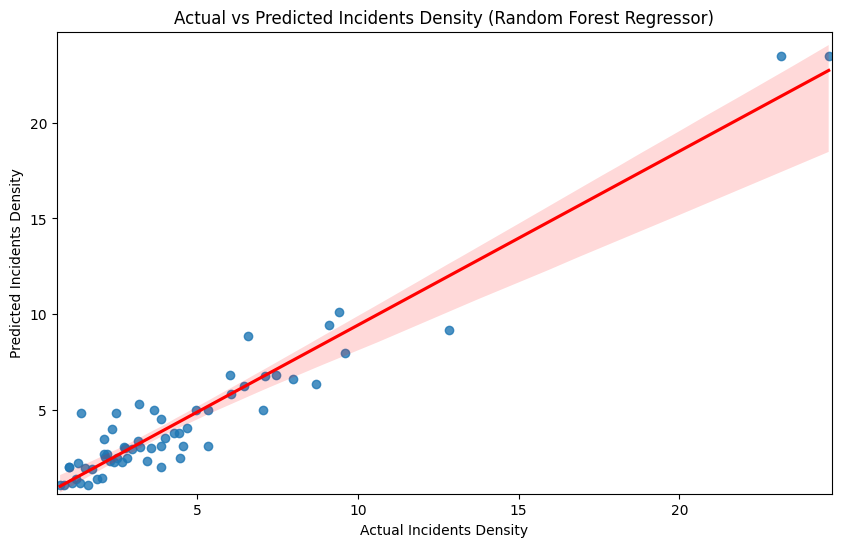

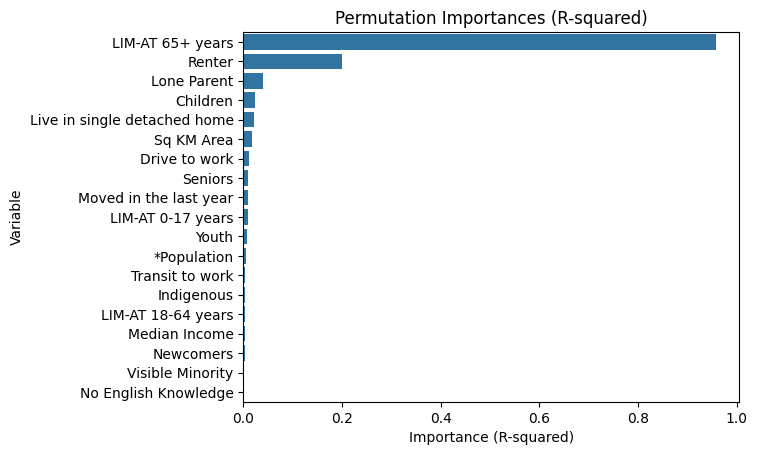

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle

target = 'Incident Density'

predictors = [
  'Children',
  'Drive to work',
  'Indigenous',
  'LIM-AT 0-17 years',
  'LIM-AT 18-64 years',
  'LIM-AT 65+ years',
  'Live in single detached home',
  'Lone Parent',
  'Moved in the last year',
  'Newcomers',
  'No English Knowledge',
  'Renter',
  'Seniors',
  'Transit to work',
  'Visible Minority',
  'Youth',
  'Median Income',
  'Sq KM Area',
  '*Population'
  ]

# X = all predictors, y = target
X = df_analysis[predictors]
y = df_analysis[target]

#Split before scaling
X, y = shuffle(X, y , random_state=2124)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#Fit Model
regressor = RandomForestRegressor(
    random_state=2124,
    n_estimators=200,
    bootstrap=True,
    max_depth=None,
    n_jobs=-1,
    #max_features=15,
    min_samples_split=2)
regressor.fit(X_train, y_train)

print("Train R²:", regressor.score(X_train, y_train))
print("Test R²:", regressor.score(X_test, y_test))

cv_scores = cross_val_score(regressor, X_train, y_train, cv=5, scoring='r2')
print(f"Mean CV R²: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

#Evaluate
y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared: {r2:.2f}')

#Plot
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, line_kws={'color': 'red'})

plt.xlabel("Actual Incidents Density")
plt.ylabel("Predicted Incidents Density")
plt.title("Actual vs Predicted Incidents Density (Random Forest Regressor)")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.xlim(min_val - 0.1, max_val + 0.1)
plt.ylim(min_val - 0.1, max_val + 0.1)

plt.show()


perm_result = permutation_importance(
    regressor,
    X_test,
    y_test,
    scoring='r2',
    n_repeats=30,
    random_state=2124
)

forest_importances = pd.DataFrame({
    'variable': X_test.columns,
    'impo': perm_result.importances_mean.round(4),
    'sd': perm_result.importances_std.round(4)
})

forest_importances.sort_values(by='impo', ascending=False, inplace=True)

sns.barplot(data=forest_importances, y='variable', x='impo')
plt.title('Permutation Importances (R-squared)')
plt.xlabel('Importance (R-squared)')
plt.ylabel('Variable')
plt.show()

#Report

## <font color='lightblue'>1. Ask a question </font>

**Q1**: Layout your question of interest. Remember to state your question as clearly and simply as you can (Mark 1), and what your ideal outcome would be (Marks 1).

The main question is: Can we fit a model of traffic incident density in the different Community Service Areas (CSAs) of Calgary based on a variety of demographic and equity measures?

A model that accurately predicts the places where incidents will be most concentrated based on their demographic makeup is what we are looking for as the ideal outcome, which can be a great help in the selection of security measures and distribution of resources.

**Q2**: Identify and describe what data sources you'll use (Marks 1). Make sure to talk about one of the following: data accuracy, reliability, validity, or sample selection. (Marks: 1)

Our data sources are from the City of Calgary's Open Data Portal. One dataset details traffic incidents from the year 2022 to the year 2024, including geometric point data. The other dataset details various equity indicators as identified by the 2021 Census, sorted by Community Service Area (CSA). We have considered that both the City of Calgary's traffic incident records and the 2021 Census are complete and accurate, so, both these datasets should be considered accurate and reliable data sources.

**Q3**: Layout what kind of ML problem you are facing and what kind of model you'll use to answer it (eg., is it unsupervised or supervised learning, and is it classification or regression). Make sure to say why. (Marks 1)

This will be a supervised learning problem since we have a single target variable that we are interested in estimating ('Incident Density') and a set of features (demographic and equity indicators) that we will train the model on. More specifically, this will be a regression problem because our target variable ('Incident Density') is a continuous numerical variable. We will be using a Random Forest Regressor model to solve this problem; the Random Forest algorithm is particularly suited for continuous outcome predictions and is adept at capturing the complex relationships between the predictor variables and the target variable.


## <font color='lightblue'>2. Data understanding, exploration, and visualization </font>

**Action**: While above you gave an overview of the dataset(s) that will be used, here make sure that the reader understands the important details of the data. E.g., show a figure or descriptive statistic and explain why the reader should know about this, i.e., how will it help your reader understand your analysis? (Marks: 2)

<Axes: >

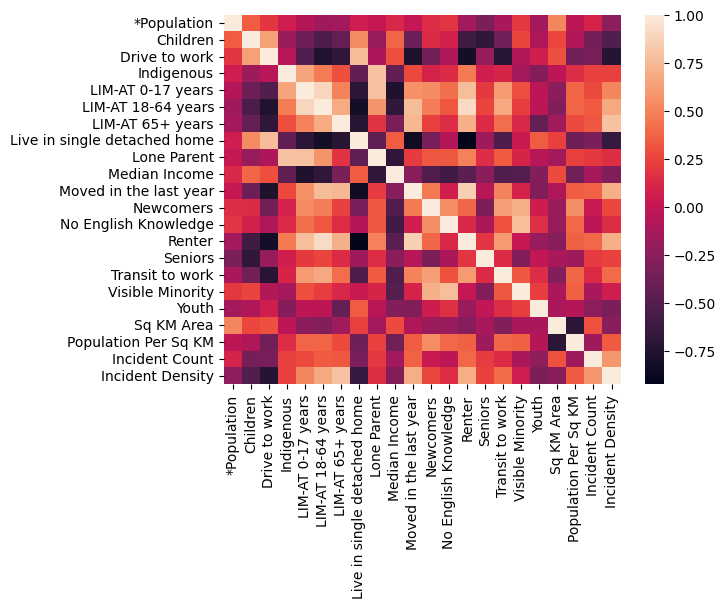

In [ ]:
data_corr = df_analysis.drop(columns=['geometry', 'csa', 'Incident Year']).corr()
sns.heatmap(data_corr, square = False)

The heatmap shown above indicates correlations between different variables within the combined dataset. Our target variable, Incident Density, indicates relatively strong correlations with a few different predictor variables, including positive correlations with LIM-AT 65+ years, Moved in the last year and Renter, and negative correlations with Drive to work and Live in single detached home. Our model will very likely weigh variables with strong correlations highly (whether they be positive or negative correlations), which would likely indicate that these variables will play a significant role in how the model estimates Incident Density.

## <font color='lightblue'>3. Data wrangling and preprocessing </font>

Data Wrangling Steps:

Initial Load:
- Each of the two datasets (Incidents and Equity) are downloaded in chunks of 25000 records. This is to avoid any unexpected truncation that typically occurs around 50000 records. Limiting to 25000 per pull helps ensure that our process will be requesting well below the website's limit per request
- To ensure consistency, the same procedure get_data() is used to retrieve both datasets, which are then saved into distinct dataframes

General Cleanup:
- refine_incidents and refine_equity contain all the unique treatments required for each respective dataset
- Each procedure includes standards functions like dropping nulls, unnecessary columns, reordering columns, and renaming
- Each procedure also projects into epsg=3395 to ensure the datasets are join compatible

Incidents Specialized Cleanup:
- Add a calculated column for year. Only 2022, 2023, 2024 will be used for the model so this column is important to filtering and aggregation
  
Equity Specialized Cleanup:
- filter to area_type = 'CSA' (as various other disparate geographic groupings exist in the dataset, and our model level is based on the CSA level)
- retain csa and geometry, pivotting all the attributes and values across columns (initially all attributes exist in a stack where each record is a different attribute)
- after pivotting, convert again to a GeoDataFrame as its geographic status will be lost during the pivot
- define a list of the metrics which are truly rates, and divide them by 100 so the format is more intuitive (initially values like 10.5% would have a value of 10.5 - setting them to a format like 0.105 helps later interpretation)
- calculate the Square Kilometer Area (Sq KM Area) of each CSA based on its geometry.area value
- calculate the Population Density (Population Per Sq KM) by dividing population count by [Sq KM Area]
- Filter to only the middle 90% of data based on Population Density (exclude below the 5th percentile and above the 95th percentile). There are some extremely dense and extremely sparse CSAs which are not suitable for training the model to predict for typical CSAs
  - the count of CSAs excluded is reported by the print functions, for reference purposes

Join the datasets:
- First, df_equity is joined to df_incidents to derive the CSA geography, so that incidents can be aggregated to Incident Year and CSA instead of the Incident's geographic point
- Next, df_incidents is left joined to df_equity based on matching csa. Left Join ensures that CSAs with zero traffic incidents are not excluded. If any such CSAs exist, they are populated with an Incident Count of zero via fillna(0)
- After joining, the variable of greatest interest can now be calculated: "Incident Density", based on number of incidents per year per Square Kilometer. This variable is the target of prediction in our model.

## <font color='lightblue'>4. Build and test a model</font>



**Action:** Use your training dataset to build a model with the goal addressing your question of interest. (Marks: 2)

Random Forest Regressor was the model chosen for this particular prediction task. The first point is that we explicitly stated our target, which was 'Incident Density', and gathered those possible predictors through equity data.

The data was divided into two main components, a set for training the model (about 80% of the data), and a separate set for testing the model (20% of the data). The performance of the model can be quantified with new data which will serve as a proper measure of the model's usefulness in real-life instances.

The `RandomForestRegressor` model was then set up for training after the training data had been prepared. We modified a few hyperparameters to achieve the desired model and exposed the model to the training data. The R-squared scores for both training and testing sets were checked because they show the amount of variation in Incident Density which can be attributed to our model. Moreover, as a form of cross-validation, training data was subjected to mini-testing which is similar to allowing the model to go through a series of tests to confirm that it is not merely overfitting the particular training data but rather has learned to generalize well. To have a glimpse of the potential discrepancies in our predictions, we worked out the Mean Squared Error and the Root Mean Squared Error.

A scatter plot was generated to compare the model's predictions to the actual Incident Density visually. Finally, we calculated the permutation importance in order to get an idea of the predictor variables' importance in the model's predictions. This helped identify the factors that were the most critical for the model when it made its predictions.

**Q4**: Measure the performance of your model, and describe how well your model generalizes to new data (Marks: 2)

Our model, a Random Forest Regressor model, achieved a Test R-squared value of 0.9242, with a mean cross-value R-squared value of 0.88 ± 0.10, and a root mean squared error of 1.21. The primary change in our model, replacing our variable of interest, Incidents Rate, with a new measure, Incidents Density, significantly increased our model's accuracy, and we further expanded our datasets with data from previous years to provide a greater base of records on which to train and test the data.

## <font color='lightblue'>5. Interpret your model</font>

**Q5**: Interpret your model results. E.g., what features contributed to your predictions, if possible, can you determine the sign and magnitude of the effect (Marks: 2).

As our heatmap above indicated, after analyzing the model's performance, some of the variables with strong correlations have strong permutation importance scores, with the strongest scores beloinging to LIM-AT 65+ years and Renter. In particular, the former provides an R-squared importance of approximately 0.95, which indicates a very strong importance in the model's performance, while the latter provides an R-squared importance of approximately 0.25. As we indicated in the heatmap above, both of these variables have positive correlations with Incident Density, indicating that higher values in these variables provide a correspondingly higher value in Incident Density.

Despite other variables with strong correlations placing relatively high in the list of predictor variables sorted by permutation importance, none have an R-squared importance higher than 0.05, indicating that these variables play a comparatively small part in the model's predictive performance. In particular, the third most important predictor variable (after the two strongest mentioned above) was Lone Parent, which according to the heatmap has a very weak positive correlation. This indicates that while a few variables with strong correlations may play a large role in the model's predictive performance, after the model takes those variables into account, the next one that the model uses may have a very weak correlation, but combined with the initial variables has a greater predictive performance.

## <font color='lightblue'>6. Answer your question</font>

**Q6:** Use your analysis above to answer your question of interest. Did you achieve your desired outcome, and what might the next steps be? Remember to write as though you are writing to team mates working on the same/similar problem. (Marks: 3)


Note: It is ok if your analysis doesn't provide a strong answer, you can point out where it failed. If anything you can cross the approach you took off the list of possible ways to tackle your question. I.e., you still made progress!

Based on the analysis we've done using the Random Forest Regressor model, we were able to predict Incident Density with a pretty good degree of accuracy. We hit a Test R-squared of 0.9242, which feels quite promising. What this really tells us is that the equity indicators we decided to look at, especially 'LIM-AT 65+ years' and 'Renter', seems to be genuinely significant when it comes to predicting where we see more traffic incidents across Calgary's different Community Service Areas. It's interesting how those two indicators popped out as being so important.

Our main goal with this was to build a model that could actually predict Incident Density using these demographic equity indicators. Looking at the results, I think it's fair to say we managed to achieve that with a reasonable level of success. The numbers from the model's performance suggest that it holds up pretty well when we feed it new data, as long as that data falls within the population density range we focused on during the training.

So, when considering what's next, one option could be to investigate more deeply the cause of the very strong relationship between 'LIM-AT 65+ years' and 'Renter', which is one of the most important factors in the model. It will also be good to look at and try to find other factors that could push the model's performance even further. Different modeling techniques are, as mentioned earlier, for instance, the Ridge Regression, will certainly help in revealing the worth of each predictor. Furthermore, it will be advantageous to look into the areas of the model's prediction where it was quite far off, to see if there are unique characteristics of those CSAs that we are not capturing in the data or modeling process. Lastly, it will be of immense help to get in touch with the municipal officials responsible for urban planning and traffic control, so that we can not only talk about but also actually implement the research findings in practice through interventions focusing or resources distribution in high incident density locations or in areas that have a larger share of the demographic groups we have identified.